# Main section

In [148]:
from pathlib import Path
import json

import pandas as pd
import numpy as np


# OLD aggregation, missing some uselef stuff thos
# names = [
#     "exp_aggregation_2ae9865c86_Bikes_20260817_131836",
#     "exp_aggregation_6ba3a8c889_Svhn_20260817_131836",
#     "exp_aggregation_97e9f1e345_Cifar10_20260817_131836",
#     "exp_aggregation_63536f9c1b_Energy_20260817_131836",
# ]
# Old predictor ambiguity, not missing anything
# names = [
#     "exp_ambiguity_gradient_b39c02fc0a_Bikes_20260819_154050",
#     "exp_ambiguity_gradient_ca1fe8e38d_Energy_20260819_154050",
#     "exp_ambiguity_gradient_d2f60c72f9_Cifar10_20260819_154050",
#     "exp_ambiguity_gradient_08ba21ef89_Svhn_20260819_154050",
# ]


# NEW
# names = [
#     "exp_aggregation_be3bf603e6_Cifar10_20260917_130453",
#     "exp_aggregation_f0318076c1_Svhn_20260917_132311",
#     "exp_aggregation_49cf2276a5_Bikes_20260917_135347",
#     "exp_aggregation_aa98ffb8ac_Energy_20260917_155850",
# ]

# names = [
#     "exp_ambiguity_gradient_6298decc33_Cifar10_20260917_160249",
#     "exp_ambiguity_gradient_f6508be9dd_Bikes_20260917_173454",
#     "exp_ambiguity_gradient_2520440d44_Svhn_20260917_173454",
#     "exp_ambiguity_gradient_18fa513726_Energy_20260918_012151",
# ]

names = [
    "exp_ambiguity_delgradient_c3881e3193_Cifar10_20260918_014816",
    "exp_ambiguity_delgradient_4ad840d50a_Svhn_20260918_040851",
    "exp_ambiguity_delgradient_697ab1ae97_Bikes_20260918_055635",
    "exp_ambiguity_delgradient_33f879453d_Energy_20260918_100653",
]


figures_folder = Path(".").resolve() / "paper" / "figures"
_bsdir = Path(".").resolve() / "runs"
run_dir = _bsdir
# run_dir = _bsdir if (names[0].split("_")[1] == "aggregation") else  _bsdir / "runs"

def parse_value(value):
    try:
        return int(value)
    except ValueError:
        return value

    


def parse_stem(path, suffix: str ="_metrics"):
    stem = path.stem.removesuffix(suffix)
    parts = stem.split("_")

    if len(parts) % 2 != 0:
        raise ValueError(f"Expected key_value pairs, got: {path.name}")

    return {
        parts[i]: parse_value(parts[i + 1])
        for i in range(0, len(parts), 2)
    }


In [149]:

dfs = []

for name in names:
    exp_dir = run_dir / name
    metric_files = sorted(exp_dir.glob("*_metrics.json"))

    parse_name = name.replace("ambiguity_gradient", "gradient").replace("ambiguity_delgradient", "delgradient")

    _, exp_type, launch_id, task, t1, t2 = parse_name.split("_")

    for path in metric_files:
        info = parse_stem(path)

        with path.open() as f:

            try:
                metrics = json.load(f)
            except json.JSONDecodeError:
                print(f"Cannot decode {path}")
                continue

        metrics = {
            k: np.asarray(v)
            for k, v in metrics.items()
        }

        shapes = {k: v.shape for k, v in metrics.items()}

        if len(set(shapes.values())) != 1:
            raise ValueError(
                f"Metric shapes differ in {path.name}: {shapes}"
            )

        shape = next(iter(shapes.values()))

        if len(shape) != 2:
            raise ValueError(
                f"Expected metrics shaped (epoch, seed), got {shape} "
                f"in {path.name}"
            )

        n_epochs, n_seeds = shape

        # Flatten in row-major order:
        # epoch 0 seed 0..N, epoch 1 seed 0..N, ...
        df_metrics = pd.DataFrame({
            k: v.reshape(-1)
            for k, v in metrics.items()
        })

        df_metrics["epoch"] = np.repeat(
            np.arange(n_epochs),
            n_seeds,
        )

        df_metrics["seed_id"] = np.tile(
            np.arange(n_seeds),
            n_epochs,
        )

        df_metrics["run_id"] = info.pop("run")
        df_metrics["task"] = task


        for key, value in info.items():
            df_metrics[key] = value

        # metrics_df["experiment"] = name

        dfs.append(df_metrics)


df = pd.concat(dfs, ignore_index=True)

df = df.sort_values(
    ["run_id", "seed_id", "epoch"]
).reset_index(drop=True)



def mean_seeds(df: pd.DataFrame):
    from pandas.api.types import is_string_dtype

    mean_columns = tuple(df.dtypes.index[df.dtypes == float])
    take_columns = tuple((set(df.dtypes.index[df.dtypes == int]) | set(df.dtypes.index[df.dtypes.apply(is_string_dtype)])) - {"seed_id"})

    group_cols = ["task", "epoch", "run_id"]
    take_columns = tuple(set(take_columns) - set(group_cols))
    mean_columns = tuple(set(mean_columns) - set(group_cols))

    g = df.groupby(group_cols, observed=True)

    nunique = g[list(take_columns)].nunique(dropna=False)
    assert (nunique <= 1).all().all(), f"Non-unique values:\n{nunique[nunique.gt(1).any(axis=1)]}"

    return g.agg(
        **{c: (c, "mean") for c in mean_columns},
        **{c: (c, "first") for c in take_columns},
    ).reset_index()

df: pd.DataFrame = df.pipe(mean_seeds)

In [150]:
def norm_entropy(x, axis, normalize: bool = False):
    x = np.asarray(x, dtype=float)
    n = x.shape[axis]

    if n == 0:
        return np.full(x.sum(axis=axis).shape, np.nan)

    assert np.all(np.isfinite(x)) and np.all(x >= 0)

    if normalize:
        x = x / np.sum(x, axis=axis, keepdims=True)
    else:
        assert np.all(np.isclose(x.sum(axis=axis), 1.0, atol=1e-5)), x.sum(axis=axis)

    if n == 1:
        return np.full(x.sum(axis=axis).shape, np.inf)

    log_x = np.zeros_like(x)
    np.log(x, out=log_x, where=x > 0)

    return -np.sum(x * log_x, axis=axis) / np.log(n)

df_metrics = []

for name in names:
    exp_dir = run_dir / name
    metric_files = sorted(exp_dir.glob("*eval_metrics.npz"))

    parse_name = name.replace("ambiguity_gradient", "gradient").replace("ambiguity_delgradient", "delgradient")

    _, exp_type, launch_id, task, t1, t2 = parse_name.split("_")

    rows = []
    for path in metric_files:
        info = parse_stem(path, suffix="_eval_metrics")

        try:
            with np.load(path) as metrics:
                predictors_weight_per_model = metrics["predictors_weight_per_model"]
                predictors_perfomance_per_model = metrics["predictors_perfomance_per_model"]
                predictors_ambiguity_per_model = metrics["predictors_ambiguity_per_model"]
                delegators_perfomance_per_model = metrics["delegators_perfomance_per_model"]
                delegators_ambiguity_per_model = metrics["delegators_ambiguity_per_model"]

                loss = metrics["loss"]
                loss_under_oracle = metrics["loss_under_oracle"]
                metric = metrics["metric"]
                metric_under_oracle = metrics["metric_under_oracle"]
        except EOFError:
            print(f"Empty file {path}")
            continue

        predictors_performance = np.mean(predictors_perfomance_per_model * predictors_weight_per_model, axis=1)
        mean_predictors_performance = np.mean(np.sum(predictors_performance, axis=-1))
        predictor_loss_entropy = np.mean(norm_entropy(predictors_performance, axis=-1, normalize=True))

        mean_predictors_ambiguity = np.mean(np.sum(predictors_ambiguity_per_model * predictors_weight_per_model, axis=-1))
    
        weights_entropy = np.mean(norm_entropy(predictors_weight_per_model, axis=-1)) 

        mean_delegators_performance = np.mean(delegators_perfomance_per_model)
        delegators_loss_entropy = np.mean(norm_entropy(np.mean(delegators_perfomance_per_model, axis=1), axis=-1, normalize=True))
        mean_delegators_ambiguity = np.mean(delegators_ambiguity_per_model)

        row = info | dict(
            weights_entropy=weights_entropy,
            delegators_ambiguity=mean_delegators_ambiguity,
            delegators_performance=mean_delegators_performance,
            predictors_ambiguity=mean_predictors_ambiguity,
            predictors_performance=mean_predictors_performance,
            predictor_loss_entropy=predictor_loss_entropy,
            delegators_loss_entropy=delegators_loss_entropy,
            final_loss=np.mean(loss),
            final_loss_under_oracle=np.mean(loss_under_oracle),
            final_metric=np.mean(metric),
            final_metric_under_oracle=np.mean(metric_under_oracle),
        )

        rows.append(row)
        
    temp = pd.DataFrame(rows)
    temp["task"] = task
    
    df_metrics.append(temp)

df_metrics: pd.DataFrame = pd.concat(df_metrics, ignore_index=True).rename(columns={"run": "run_id"})
df_metrics["final_loss_better"] = df_metrics["final_loss_under_oracle"]
mask = df_metrics["final_loss_better"] > df_metrics["final_loss"]
df_metrics.loc[mask, "final_loss_better"] = df_metrics.loc[mask, "final_loss"]
df_metrics["regret"] = (df_metrics["final_loss"] - df_metrics["final_loss_better"]) # / df_metrics["final_loss"]

In [151]:
appendix_pred_ambiguity = False

pambiguity = r"\mathcal{A}_{\mathrm{P}}"
dambiguity = r"\mathcal{A}_{\mathrm{D}}"

if exp_type == "gradient":
    if appendix_pred_ambiguity:
        exp_type = "appendix_gradient"
    else:
        df = df[~(df["ambiguitypred"] == "both")]
        df_metrics = df_metrics[~(df_metrics["ambiguitypred"] == "both")]

        condition_labels = {
            "none": (
                rf"\mathrm{{off}}\;{pambiguity}",
                rf"\mathbf{{off}}\;{pambiguity}",
            ),
            "delegators": (
                rf"\mathrm{{on}}\;{pambiguity}",
                rf"\mathbf{{on}}\;{pambiguity}",
            ),
        }

elif exp_type == "delgradient":
    condition_labels = {
        "False": (
            rf"\mathrm{{off}}\;{dambiguity}",
            rf"\mathbf{{off}}\;{dambiguity}",
        ),
        "True": (
            rf"\mathrm{{on}}\;{dambiguity}",
            rf"\mathbf{{on}}\;{dambiguity}",
        ),
    }
else:
    condition_labels = {}

In [152]:
exp_vars = ["predictors", "delegators", "pwidth", "dwidth"]
var_oi = {
    "aggregation": "mixing",
    "gradient": "ambiguitypred",
    "delgradient": "ambiguitydele",
    "appendix_gradient": "ambiguitypred"
}[exp_type]
var_oi_values = df[var_oi].unique().tolist()
temp = var_oi_values[1]
var_oi_values[1] = var_oi_values[0]
var_oi_values[0] = temp
val_loss_col = "validation_performance_loss"
train_loss_col = "performance_loss"

def get_metric_col(task):
    if task in {"Cifar10", "Svhn"}:
        return "validation_accuracy_metric"
    elif task in {"Bikes", "Energy"}:
        return "validation_r2_metric" 
    else:
        raise ValueError(f"Unknown task {task}")

In [153]:
from typing import Literal

from matplotlib import pyplot as plt


def pair_up(df: pd.DataFrame, single_task: bool =True):
    if single_task:
        return _pair_up(df)
    else:
        out = []
        for task, task_df in df.groupby("task"):
            out.append(_pair_up(task_df, prefix_with=task))
        return pd.concat(out, ignore_index=True)

def _pair_up(single_task: pd.DataFrame, prefix_with: str = ""):

    n_in_pair = len(var_oi_values)

    if n_in_pair < 1:
        raise ValueError("n_in_pair must be >= 1")

    if single_task.duplicated("run_id").any():
        raise ValueError("Run id duplicates")

    single_task = single_task.copy()

    # Intended groups: (1,2), (3,4), ...
    single_task["pair_id"] = (single_task["run_id"] - 1) // n_in_pair
    single_task["pair_id"] = single_task["pair_id"].astype("string")

    if prefix_with:
        single_task["pair_id"] = prefix_with + "_" + single_task["pair_id"] 

    # Delete groups with missing runs
    complete_pairs = (
        single_task.groupby("pair_id")["run_id"]
        .nunique()
        .eq(n_in_pair)
    )

    single_task = single_task[
        single_task["pair_id"].isin(complete_pairs.index[complete_pairs])
    ].copy()

    inconsistent = (
        single_task.groupby("pair_id")[exp_vars]
        .nunique(dropna=False)
        .gt(1)
        .any(axis=1)
    )

    if inconsistent.any():
        bad = inconsistent.index[inconsistent].tolist()
        raise ValueError(f"Pairs contain inconsistent exp_vars: {bad}")

    return single_task.reset_index(drop=True)

def select_last(df: pd.DataFrame):
    return (
        df
        .sort_values(["task", "run_id", "epoch"])
        .groupby(["task", "run_id"])
        .tail(1)
    )


def select_early_stopping(df: pd.DataFrame):
    idx = (
        df
        .groupby(["task", "run_id"])[val_loss_col]
        .idxmin()
    )
    return df.loc[idx].copy()

def add_metrics(df: pd.DataFrame):

    common_cols = list(set(df.columns) & set(df_metrics.columns))
    df_merged = pd.merge(df, df_metrics, "left", on=common_cols, validate="1:1")
    return df_merged

def pivot_to_metrics(paired: pd.DataFrame, *cols: str):

    cols = list(cols)

    if len(cols) == 0:
        cols = [val_loss_col]

    if len(cols) == 1:
        cols = cols[0]

    return pd.pivot(paired, index="pair_id", columns=var_oi, values=cols)

def scale_up_fonts(fig, scale: float = 1.3):


    for ax in fig.axes:
        ax.title.set_fontsize(ax.title.get_fontsize() * scale)
        ax.xaxis.label.set_fontsize(ax.xaxis.label.get_fontsize() * scale)
        ax.yaxis.label.set_fontsize(ax.yaxis.label.get_fontsize() * scale)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontsize(label.get_fontsize() * scale)

        legend = ax.get_legend()
        if legend is not None:
            for text in legend.get_texts():
                text.set_fontsize(text.get_fontsize() * scale)
    


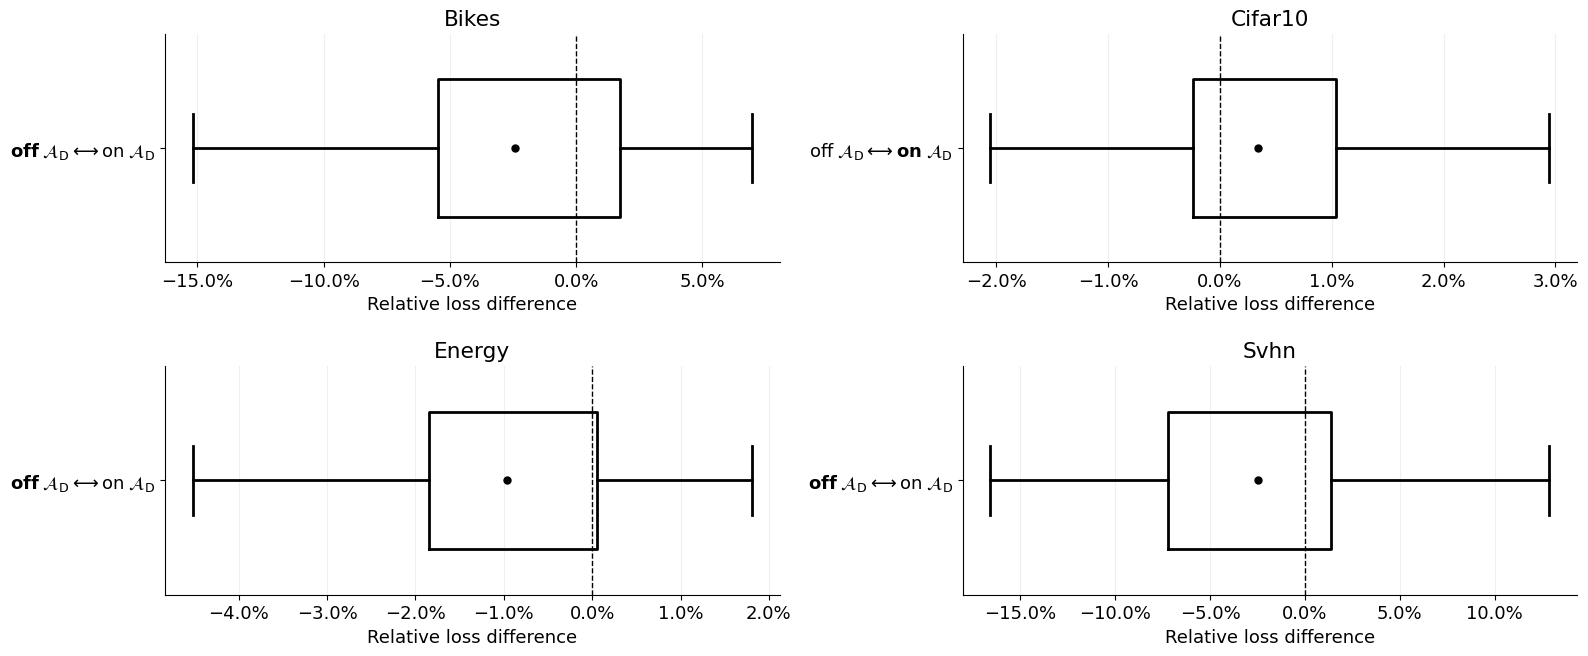

In [154]:
import itertools



def plot_relative_diff(
    pivot: pd.DataFrame,
    ax,
    xlabel: str,
    larger_better: bool,
    cols: list,
    lw: int = 2,
    rotate_yticks: bool = False
):
    from itertools import combinations
    from matplotlib.ticker import PercentFormatter

    data = []
    labels = []

    for l, r in combinations(cols, 2):
        l_vals = pivot[l]
        r_vals = pivot[r]

        diff = (l_vals - r_vals) / ((l_vals + r_vals) / 2)
        diff = diff.dropna()
        mean_diff = diff.mean()



        def format_label(x, bold=False):
            if x in condition_labels:
                normal, bold_label = condition_labels[x]
                return bold_label if bold else normal

            label = str(x).replace("_", " ").title()
            return rf"\mathbf{{{label}}}" if bold else rf"\mathrm{{{label}}}"

        l_better = (
            (mean_diff > 0 and larger_better)
            or (mean_diff < 0 and not larger_better)
        )

        r_better = (
            (mean_diff < 0 and larger_better)
            or (mean_diff > 0 and not larger_better)
        )

        ll = format_label(l, l_better)
        rr = format_label(r, r_better)

        label = rf"${ll} \longleftrightarrow {rr}$"

        data.append(diff)
        labels.append(label)

    ax.boxplot(
        data,
        vert=False,
        tick_labels=labels,
        widths=0.6,
        showmeans=True,
        meanline=False,
        showfliers=False,
        boxprops={"linewidth": lw},
        whiskerprops={"linewidth": lw},
        capprops={"linewidth": lw},
        medianprops={"linewidth": 0},
        meanprops={
            "marker": "o",
            "markerfacecolor": "black",
            "markeredgecolor": "black",
            "markersize": 5,
        },
    )

    ax.axvline(0, color="black", linestyle="dashed", linewidth=1)

    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.set_xlabel(xlabel)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.2)

    if rotate_yticks:
        ax.tick_params(axis="y", labelrotation=90, pad=12)

        for label in ax.get_yticklabels():
            label.set_horizontalalignment("center")
            label.set_verticalalignment("center")

early_stopping = True

n_tasks = df["task"].nunique()

subsubs = len(list(itertools.combinations(var_oi_values, 2)))

fig, axs = plt.subplots(
    2,
    2,
    figsize=(16, 10 / 3 * max(subsubs, 2)),
    squeeze=False,
)
axs = axs.flat

for i_task, (task, task_df) in enumerate(df.groupby("task")):
    axl = axs[i_task]
    axl.set_title(task, fontsize=12)

    (
        task_df
        .pipe(select_early_stopping if early_stopping else select_last)
        .pipe(pair_up)
        .pipe(pivot_to_metrics)
        .pipe(lambda x: plot_relative_diff(x, axl, xlabel="Relative loss difference", larger_better=False, cols=var_oi_values, rotate_yticks=False))
    )

scale_up_fonts(fig)


fig.tight_layout(h_pad=2.0)
fig.savefig(figures_folder / f"{exp_type}_box_validation_plot_{'early' if early_stopping else 'last'}.pdf")

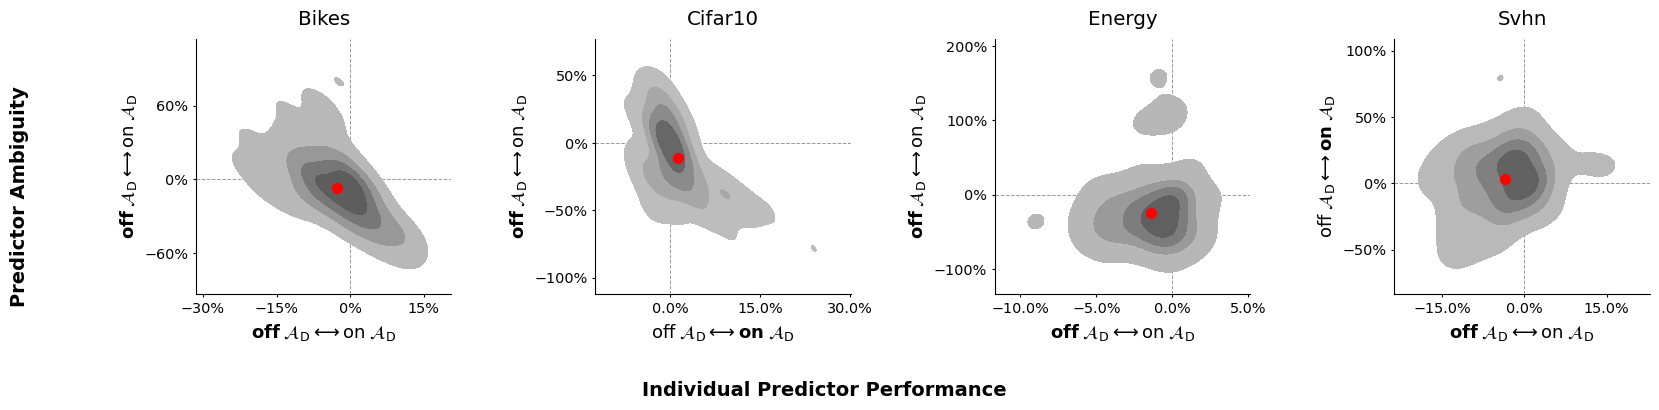

In [155]:
def plot_relative_diff_2d(
    pivot: pd.DataFrame,
    ax,
    metrics: tuple[str, str],
    pair: tuple,
    metric_labels: tuple[str, str],
    larger_better: tuple[bool, bool],
    levels: int = 5,
    thresh: float = 0.05,
    fill: bool = False,
    zero_proximity: float = 0.25,
    extra_pad: float = 0.5
):
    import numpy as np
    import pandas as pd
    import seaborn as sns
    from matplotlib.ticker import PercentFormatter, MaxNLocator

    metric_x, metric_y = metrics
    metric_label_x, metric_label_y = metric_labels
    l, r = pair

    lx = pivot[(metric_x, l)]
    rx = pivot[(metric_x, r)]

    ly = pivot[(metric_y, l)]
    ry = pivot[(metric_y, r)]

    # dx = (lx - rx) / ((lx + rx) / 2)
    # dy = (ly - ry) / ((ly + ry) / 2)
    dx = (lx - rx) / ((lx.abs() + rx.abs()) / 2)
    dy = (ly - ry) / ((ly.abs() + ry.abs()) / 2)

    if larger_better[0]:
        dx = -dx
     
    if larger_better[1]:
        dy = -dy
        

    diff = (
        pd.concat(
            {
                "x": dx,
                "y": dy,
            },
            axis=1,
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(diff) == 0:
        ax.set_axis_off()
        return

    has_2d_variation = (
        len(diff) >= 3
        and diff["x"].nunique() > 1
        and diff["y"].nunique() > 1
    )

    if has_2d_variation:
        sns.kdeplot(
            data=diff,
            x="x",
            y="y",
            fill=fill,
            levels=levels,
            thresh=thresh,
            linewidths=1.2 if not fill else None,
            ax=ax,
            color="black",
        )
    else:
        ax.scatter(
            diff["x"],
            diff["y"],
            s=12,
            alpha=0.5,
        )

    def padded_limits(lo, hi, frac=0.08):
        span = hi - lo

        if span <= 0:
            span = max(abs(lo), 1e-6)

        return (
            lo - frac * span,
            hi + frac * span,
        )

    def zero_is_near(lo, hi, proximity):
        if lo <= 0 <= hi:
            return True

        span = hi - lo

        if span <= 0:
            return False

        distance_to_range = lo if lo > 0 else -hi

        return distance_to_range <= proximity * span

    xmin, xmax = padded_limits(*ax.get_xlim())
    ymin, ymax = padded_limits(*ax.get_ylim())

    show_x_zero = zero_is_near(
        xmin,
        xmax,
        zero_proximity,
    )
    show_y_zero = zero_is_near(
        ymin,
        ymax,
        zero_proximity,
    )

    # If zero is included, put it exactly in the center.
    if show_x_zero:
        m = max(abs(xmin), abs(xmax))
        xmin, xmax = -m, m

    if show_y_zero:
        m = max(abs(ymin), abs(ymax))
        ymin, ymax = -m, m

    # Same numerical extent on x and y within this subplot.
    # lo, hi = min(xmin, ymin), max(xmax, ymax)
    # pad = extra_pad * (hi - lo)
    # lo, hi = lo - pad, hi + pad

    # xmin, xmax = ymin, ymax = lo, hi

    # ax.set_xlim(xmin, xmax)
    # ax.set_ylim(ymin, ymax)

    xpad = extra_pad * (xmax - xmin)
    ypad = extra_pad * (ymax - ymin)

    xmin, xmax = xmin - xpad, xmax + xpad
    ymin, ymax = ymin - ypad, ymax + ypad

    if show_x_zero:
        ax.axvline(
            0,
            color="black",
            linestyle="--",
            linewidth=0.7,
            alpha=0.4,
            zorder=0,
        )

    if show_y_zero:
        ax.axhline(
            0,
            color="black",
            linestyle="--",
            linewidth=0.7,
            alpha=0.4,
            zorder=0,
        )

    mu_dx = diff["x"].mean()
    mu_dy = diff["y"].mean()

    ax.scatter(
        mu_dx,
        mu_dy,
        s=50,
        color="red",
        zorder=10,
        marker="o",
    )

    ax.xaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )
    ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )

    ax.xaxis.set_major_locator(
        MaxNLocator(nbins=4)
    )
    ax.yaxis.set_major_locator(
        MaxNLocator(nbins=4)
    )

    def format_label(x, bold=False):
        if x in condition_labels:
            normal, bold_label = condition_labels[x]
            return bold_label if bold else normal

        label = str(x).replace("_", " ").title()
        return (
            rf"\mathbf{{{label}}}"
            if bold
            else rf"\mathrm{{{label}}}"
        )


    # dx/dy have already been sign-flipped above according to larger_better,
    # so negative means left is better, positive means right is better.
    xl_label = format_label(l, bold=mu_dx < 0)
    xr_label = format_label(r, bold=mu_dx > 0)

    yl_label = format_label(l, bold=mu_dy < 0)
    yr_label = format_label(r, bold=mu_dy > 0)

    ax.set_xlabel(
        rf"${xl_label} \longleftrightarrow {xr_label}$"
    )
    ax.set_ylabel(
        rf"${yl_label} \longleftrightarrow {yr_label}$"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(False)

    ax.tick_params(
        axis="both",
        labelsize=8,
        length=2,
    )

    ax.set_box_aspect(1)


from itertools import combinations

early_stopping = True

tasks = list(df["task"].unique())
pairs = list(combinations(var_oi_values, 2))

n_tasks = len(tasks)
n_pairs = len(pairs)

fig, axs = plt.subplots(
    n_pairs,
    n_tasks,
    figsize=(
        4.2 * n_tasks,
        4.2 * n_pairs,
    ),
    squeeze=False,
    sharex=False,
    sharey=False,
)

for i_task, (task, task_df) in enumerate(df.groupby("task")):
    pivot = (
        task_df
        .pipe(select_early_stopping if early_stopping else select_last)
        .pipe(pair_up)
        .pipe(add_metrics)
        .pipe(
            lambda df: pivot_to_metrics(
                df,
                "predictors_performance",
                "predictors_ambiguity",
            )
        )
    )

    for i_pair, pair in enumerate(pairs):
        ax = axs[i_pair, i_task]

        plot_relative_diff_2d(
            pivot,
            ax,
            metrics=(
                "predictors_performance",
                "predictors_ambiguity",
            ),
            metric_labels=(
                "loss",
                "ambiguity",
            ),
            pair=pair,
            larger_better=(False, True),
            fill=True,
            levels=5,
            zero_proximity=10000,
            extra_pad=0
        )

        # Only task names remain as column titles.
        if i_pair == 0:
            ax.set_title(
                str(task),
                fontsize=11,
                pad=10,
            )


scale_up_fonts(fig)

fig.supxlabel(
    "Individual Predictor Performance",
    fontsize=14,
    fontweight="bold",
    y=0.015,
)

fig.supylabel(
    "Predictor Ambiguity",
    fontsize=14,
    fontweight="bold",
    x=0.015,
)

fig.subplots_adjust(hspace=0.3, wspace=0.5)

fig.tight_layout(
    w_pad=2.5,
    h_pad=2.5,
    rect=[0.05, 0.05, 1.0, 1.0]
)

fig.savefig(figures_folder / f"{exp_type}_2ddist_predictors_ambiguity_performance.pdf")

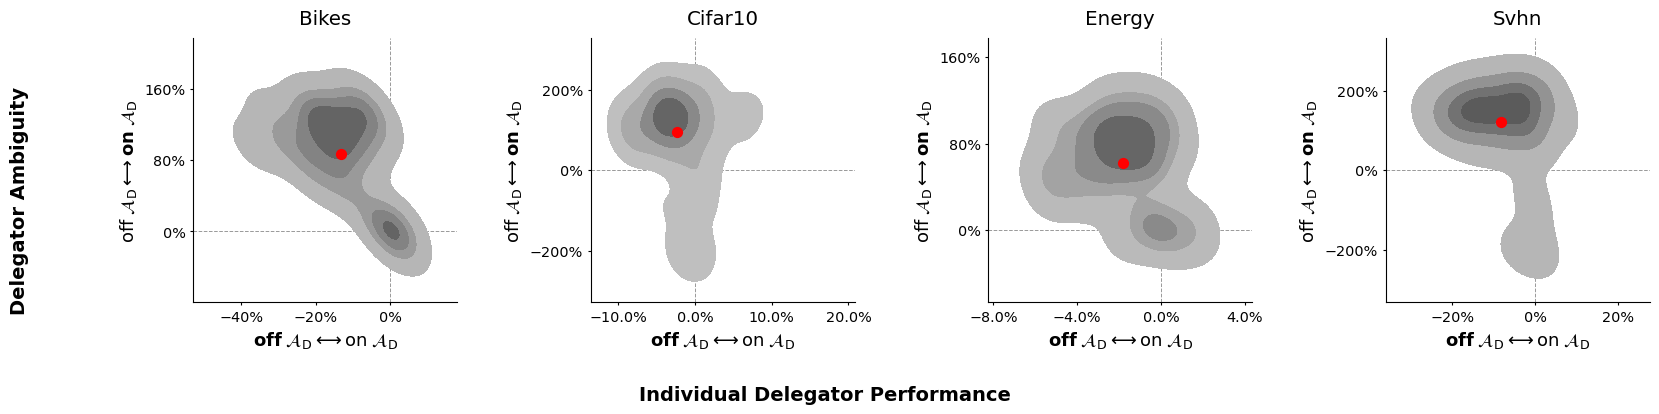

In [156]:
from itertools import combinations

early_stopping = True

tasks = list(df["task"].unique())
pairs = list(combinations(var_oi_values, 2))

n_tasks = len(tasks)
n_pairs = len(pairs)

fig, axs = plt.subplots(
    n_pairs,
    n_tasks,
    figsize=(
        4.2 * n_tasks,
        4.2 * n_pairs,
    ),
    squeeze=False,
    sharex=False,
    sharey=False,
)

for i_task, (task, task_df) in enumerate(df.groupby("task")):
    pivot = (
        task_df
        .pipe(select_early_stopping if early_stopping else select_last)
        .pipe(pair_up)
        .pipe(add_metrics)
        .pipe(
            lambda df: pivot_to_metrics(
                df,
                "delegators_performance",
                "delegators_ambiguity",
            )
        )
    )

    for i_pair, pair in enumerate(pairs):
        ax = axs[i_pair, i_task]

        plot_relative_diff_2d(
            pivot,
            ax,
            metrics=(
                "delegators_performance",
                "delegators_ambiguity",
            ),
            metric_labels=(
                "loss",
                "ambiguity",
            ),
            pair=pair,
            larger_better=(False, True),
            fill=True,
            levels=5,
            zero_proximity=10000,
            extra_pad=0
        )

        # Only task names remain as column titles.
        if i_pair == 0:
            ax.set_title(
                str(task),
                fontsize=11,
                pad=10,
            )


scale_up_fonts(fig)

fig.supxlabel(
    "Individual Delegator Performance",
    fontsize=14,
    fontweight="bold",
    y=0.015,
)

fig.supylabel(
    "Delegator Ambiguity",
    fontsize=14,
    fontweight="bold",
    x=0.015,
)

fig.subplots_adjust(hspace=0.3, wspace=0.5)

fig.tight_layout(
    w_pad=2.5,
    h_pad=2.5,
    rect=[0.05, 0.05, 1.0, 1.0]
)

fig.savefig(figures_folder / f"{exp_type}_2ddist_delegators_ambiguity_performance.pdf")

Restricted oracle improved loss in:
True    1.0
Name: proportion, dtype: float64


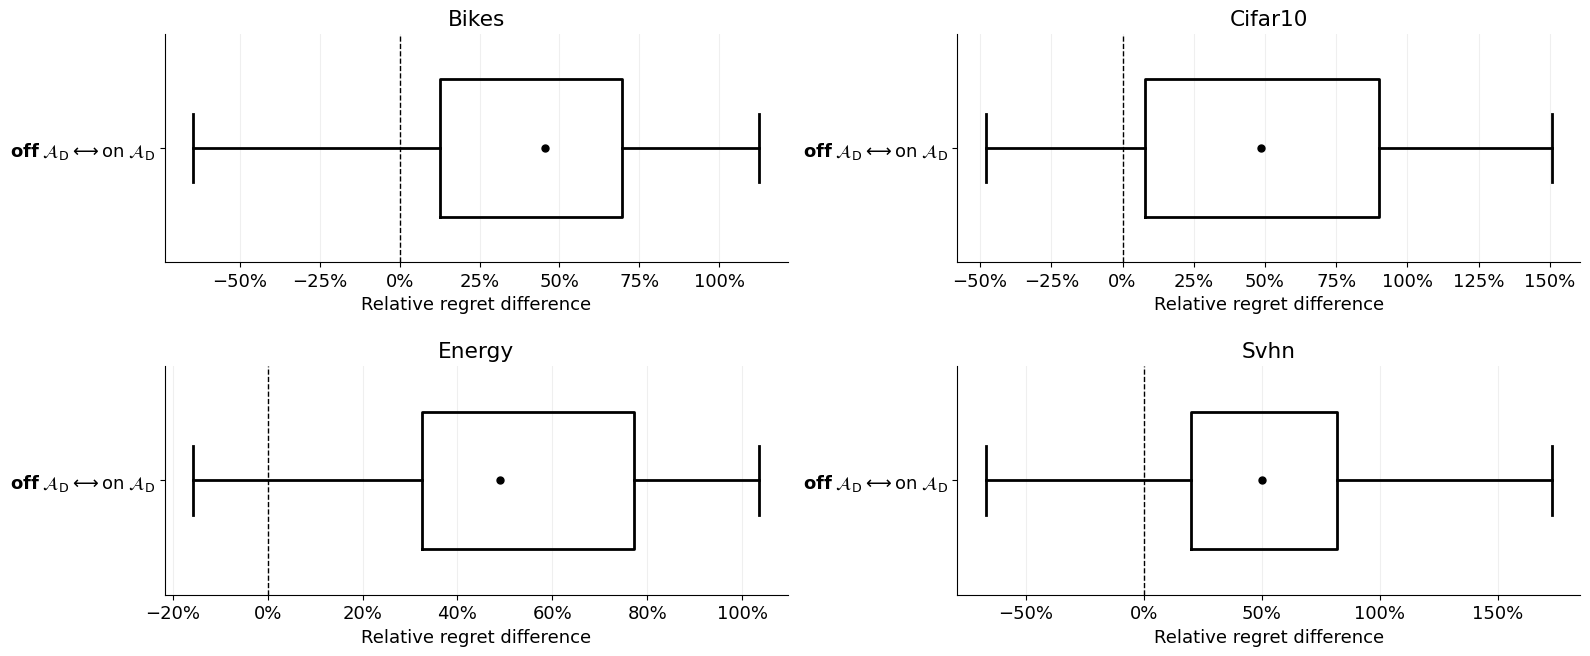

In [157]:
fig, axs = plt.subplots(
    2,
    2,
    figsize=(16, 10 / 3 * max(subsubs, 2)),
    squeeze=False,
)
axs = axs.flat

improved = df_metrics["final_loss"] > df_metrics["final_loss_under_oracle"]
print(f"Restricted oracle improved loss in:")
print(improved.value_counts(normalize=True))

for i_task, (task, task_df) in enumerate(df.groupby("task")):
    axl = axs[i_task]
    axl.set_title(task, fontsize=12)

    (
        task_df
        .pipe(select_early_stopping if early_stopping else select_last)
        .pipe(add_metrics)
        .pipe(pair_up)
        .pipe(lambda df: pivot_to_metrics(df, "regret"))
        .pipe(lambda x: plot_relative_diff(x, axl, xlabel="Relative regret difference", larger_better=True, cols=var_oi_values))
    )

scale_up_fonts(fig)

fig.tight_layout(h_pad=2.0)
fig.savefig(figures_folder / f"{exp_type}_box_regret_diff_bold_means_more_delegator_regret.pdf")

# Secondary: Gradient experiment: is delegator only condition better with increasing sizes of predictors? 

In [ ]:
paired = (
        df
        .pipe(select_early_stopping)
        .pipe(lambda df: pair_up(df, single_task=False))
        .pipe(lambda df: pivot_to_metrics(df, val_loss_col, train_loss_col, "pwidth"))
    )

paired

validation_performance_loss_casted                       \
ambiguity                               both delegators      none   
pair_id                                                             
Bikes_0                             0.049584   0.042097  0.045477   
Bikes_1                             0.059956   0.074317  0.079329   
Bikes_10                            0.046417   0.058419  0.067834   
Bikes_11                            0.052045   0.056294  0.059975   
Bikes_12                            0.043071   0.050747  0.058733   
...                                      ...        ...       ...   
Svhn_95                             0.366424   0.366123  0.417744   
Svhn_96                             0.443936   0.655652  0.659425   
Svhn_97                             0.495775   0.702107  0.664555   
Svhn_98                             0.300409   0.367597  0.421955   
Svhn_99                             0.503466   0.656189  0.762352   

          performance_loss_casted                      pwidth                   
ambiguity                    both delegators      none   both delegators  none  
pair_id                                                                         
Bikes_0                  0.009541   0.010831  0.014517   16.0       16.0  16.0  
Bikes_1                  0.026215   0.048583  0.060005    4.0        4.0   4.0  
Bikes_10                 0.017106   0.023533  0.036192    4.0        4.0   4.0  
Bikes_11                 0.015232   0.026308  0.026467   16.0       16.0  16.0  
Bikes_12                 0.009626   0.013503  0.019558   16.0       16.0  16.0  
...                           ...        ...       ...    ...        ...   ...  
Svhn_95                  0.347311   0.349250  0.397082   16.0       16.0  16.0  
Svhn_96                  0.425932   0.654716  0.662268    4.0        4.0   4.0  
Svhn_97                  0.484286   0.703662  0.666581    4.0        4.0   4.0  
Svhn_98                  0.265926   0.340238  0.402604   16.0       16.0  16.0  
Svhn_99                  0.497932   0.643641  0.764053    4.0        4.0   4.0  

[399 rows x 9 columns]

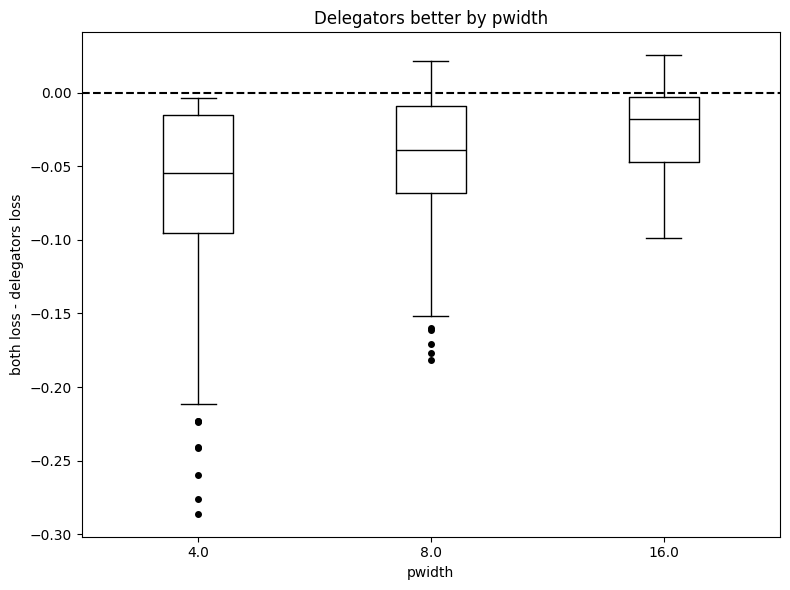

In [39]:
delegators_better = paired[(val_loss_col, "both")] - paired[(val_loss_col, "delegators")]
pwidth = paired[("pwidth", "none")]

grouped = delegators_better.groupby(pwidth, sort=True)

labels = [str(k) for k, _ in grouped]
data = [v.dropna().to_numpy() for _, v in grouped]

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    data,
    tick_labels=labels,
    vert=True,
    boxprops=dict(color="black"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    medianprops=dict(color="black"),
    flierprops=dict(
        marker="o",
        markeredgecolor="black",
        markerfacecolor="black",
        markersize=4,
    ),
)

ax.axhline(0, color="black", linestyle="dashed")
ax.set_xlabel("pwidth")
ax.set_ylabel("both loss - delegators loss")
ax.set_title("Delegators better by pwidth")

plt.tight_layout()
plt.show()

Opa we can see clear trend supporting theory: as the predictors get more capable (perfect intrepolators) the delegator condition becomes more viable. The theory that one should not explicitly maximize variance (condition "both") mostly applies when the predictors are perfect interpolators.

Lets check it a bit more precisely with a performance training loss

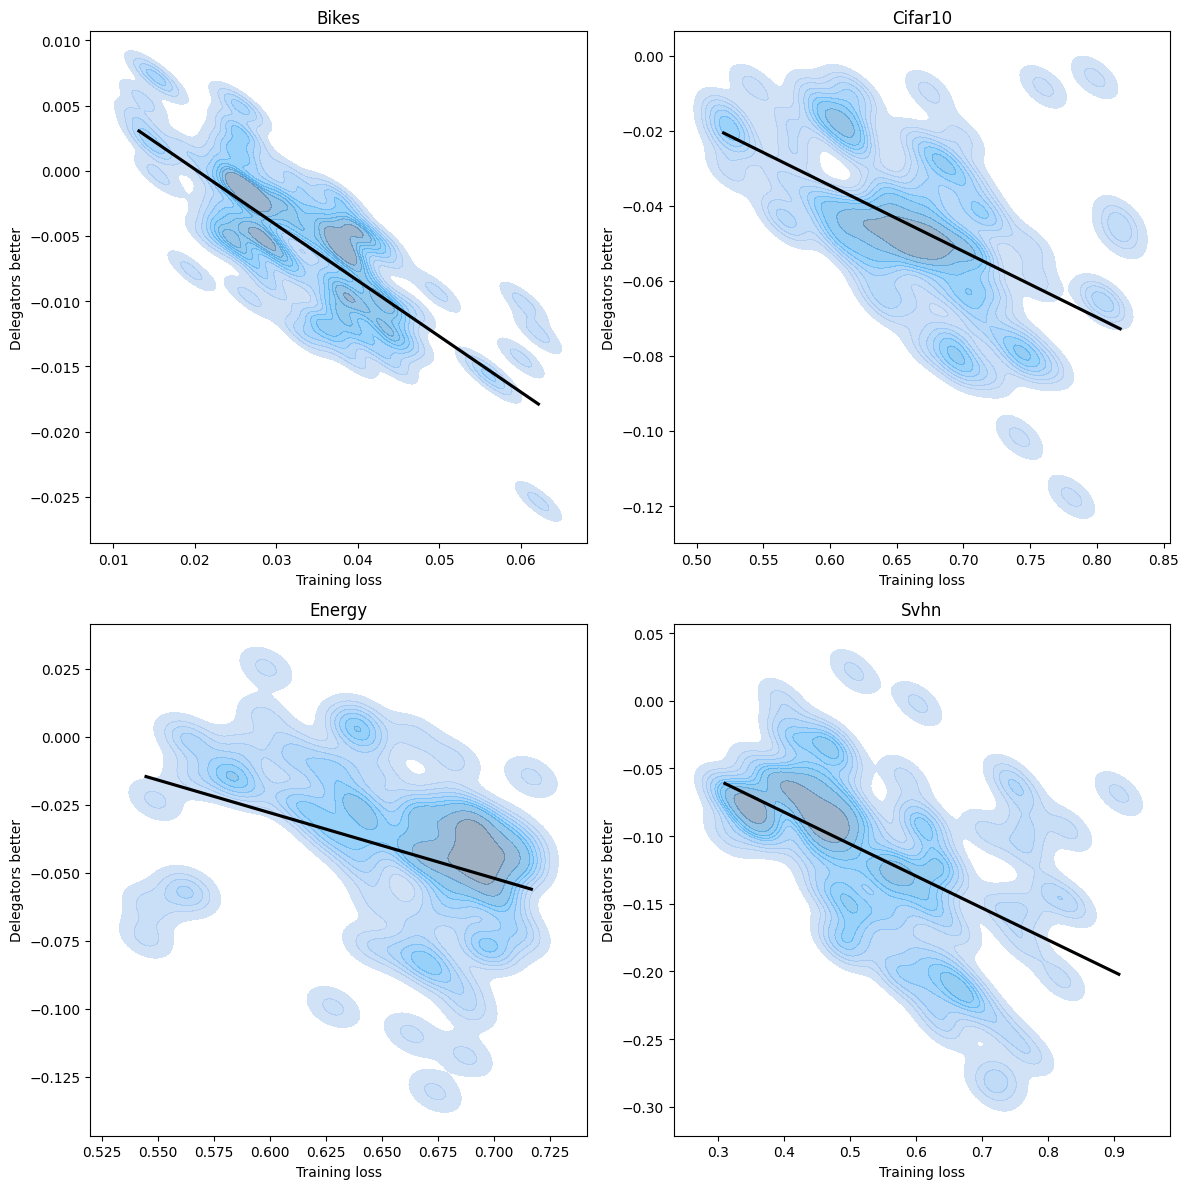

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

tasks = paired.index.to_series().str.split("_").str[0].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for task, ax in zip(tasks, axes.flat):
    mask = paired.index.to_series().str.startswith(f"{task}_")

    training_loss = paired.loc[mask, ("performance_loss_casted", "none")]
    delegators_better_task = delegators_better.loc[mask]

    sns.kdeplot(
        x=training_loss,
        y=delegators_better_task,
        fill=True,
        alpha=.5,
        ax=ax,
        bw_adjust=0.4,
    )
    sns.regplot(
        x=training_loss,
        y=delegators_better_task,
        scatter=False,
        ci=None,
        ax=ax,
        color="black",
    )

    ax.set_title(task)
    ax.set_xlabel("Training loss")
    ax.set_ylabel("Delegators better")

plt.tight_layout()

<Axes: ylabel='Density'>

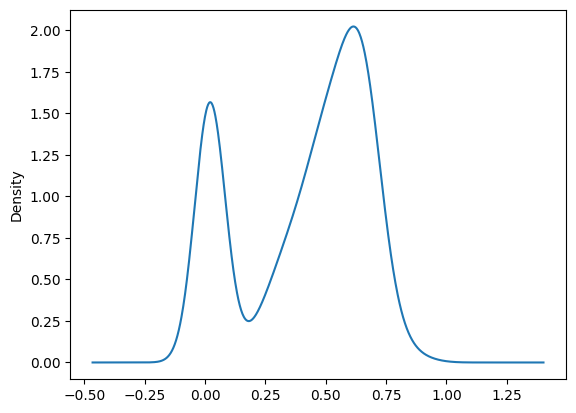

In [14]:
select_last(df)[train_loss_col].plot.density()

In [102]:
df.groupby("run_id").size()

run_id
1      21000
2      21000
3      21000
4      21000
5      21000
       ...  
296    21000
297    21000
298    21000
299    21000
300    21000
Length: 300, dtype: int64